In [76]:
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline

sys.path.append(os.path.abspath(os.path.join('..')))

In [77]:
from src.data_preprocessing import clean_data, get_preprocessing_pipeline, add_features

In [78]:
df = pd.read_csv('../data/raw_data.csv')
df = clean_data(df)

In [79]:
X = df.drop('Churn', axis=1)
y = df['Churn']

kfold = StratifiedKFold(shuffle=True, random_state=67)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=67, stratify=y)

In [80]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = [col for col in X.columns if col not in num_features]

In [81]:
pipeline = Pipeline(steps=[
    ('preprocessing', get_preprocessing_pipeline(num_features, cat_features)),
    ('model', LogisticRegression(class_weight='balanced'))
])

In [82]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_valid)

print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1031
           1       0.50      0.81      0.62       371

    accuracy                           0.74      1402
   macro avg       0.71      0.76      0.71      1402
weighted avg       0.80      0.74      0.75      1402



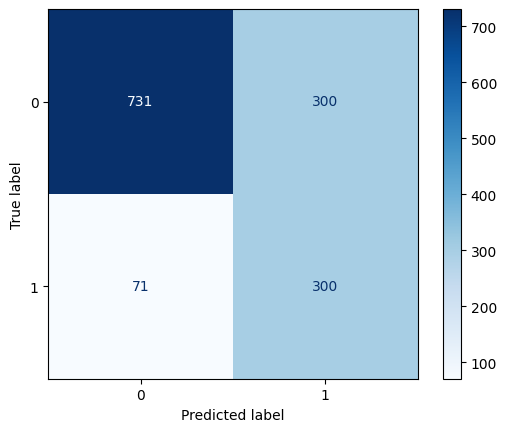

In [83]:
ConfusionMatrixDisplay.from_estimator(pipeline, X_valid, y_valid, cmap='Blues')

plt.show()

I experimented with feature engineering (tenure binning, service counting), but since I'm using a linear Baseline (Logistic Regression), these features introduced multicollinearity and slightly decreased performance. I decided to stick with the original cleaned features for the Baseline to keep the model simple and interpretable.